# W07 · Cross-Family Explainability — SHAP, Attention, and RL Value/Saliency

Hongyu LIU · InGen Dynamics — ML & NN Analyst Intern, August 2026

**Platform:** all platforms — explainability & deployment · full PIC 2.0
**Seed:** 42 (documented per section where a different protocol seed applies)
**Deployment gates:** Aido Rover ≤100 ms · Fari ≤35 ms · Senpai ≤100 ms · Aido Humanoid ≤50 ms

Phase D opens by asking *why* the Phase A–C models decide what they decide: SHAP for the classical
model and the MLP across three tasks, attention as the transformer's lens, value and input-saliency
views for the RL policies, and bias/variance diagnosis via learning curves. The classical family is
RandomForest alone — one model, not the plan's five; every "classical" statement below is scoped
accordingly.

In [1]:
import json, sys, timeit, warnings
from pathlib import Path
import numpy as np, pandas as pd, torch
import matplotlib.pyplot as plt
warnings.filterwarnings('ignore')
sys.path.insert(0, '..')
torch.set_num_threads(1)

SEED = 42
np.random.seed(SEED); torch.manual_seed(SEED)
BLUE, ORANGE, GREEN, RED, GREY = '#4C72B0', '#DD8452', '#55A868', '#C44E52', '#8C8C8C'
IMG_DIR = Path('../reports/image/W07_Explainability'); IMG_DIR.mkdir(parents=True, exist_ok=True)
DATA = Path('../data')


def save(fig, name):
    fig.savefig(IMG_DIR / name, bbox_inches='tight', dpi=130)

## 1. Deterministic Refits and Saved Checkpoints

No Week 2–4 notebook persisted a fitted model, so every explainability target here is refit from its
documented configuration (architecture, seed 42, canonical split, early stopping) and verified
against the ledger before any attribution is computed. The refit code lives in
`shared_modules/refit.py` — one definition, imported by this notebook and the Pareto notebook — and
the fitted objects are written to `saved_models/` so Week 8 can reproduce every result from disk.

In [2]:
from shared_modules.refit import save_all, load_model, SAVED_DIR

manifest = save_all()          # runs every refit, verifies against published metrics, persists
pd.DataFrame(manifest).T


device: cuda   saved under: /home/lhy/ingen_ml/hongyu-ingen-ml-analyst/saved_models
model                    metric           target   achieved   |delta|  round-trip
---------------------------------------------------------------------------------
fari/mlp                 threshold        0.4000     0.4000    0.0000    0.00e+00
                         test_f1          0.7555     0.7555    0.0000            
                         test_auc         0.8229     0.8229    0.0000            
fari/rf                  threshold        0.4300     0.4300    0.0000    0.00e+00
                         test_f1          0.7559     0.7559    0.0000            
                         test_auc         0.8077     0.8077    0.0000            
rover/cnn                threshold        0.7800     0.7300    0.0500    0.00e+00
                         test_f1          0.7317     0.6977    0.0340            
                         test_auc         0.9585     0.9587    0.0002            
rover/gru    

,file,file_bytes,scaler_file,threshold,config,metrics,verification,round_trip_max_abs_diff
rover/rf,rover/rf.joblib,5506594,None,0.49,"{'seed': 42, 'n_estimators': 200, 'max_depth':...","{'test_f1': 0.7359454855195912, 'test_f1_defau...","[{'metric': 'threshold', 'target': 0.49, 'achi...",0.0
rover/mlp,rover/mlp.pt,22181,rover/mlp_scaler.joblib,0.76,"{'seed': 42, 'in_dim': 40, 'hidden': [64, 32],...","{'test_f1': 0.735812133072407, 'test_f1_defaul...","[{'metric': 'threshold', 'target': 0.76, 'achi...",0.0
rover/cnn,rover/cnn.pt,49621,rover/cnn_scaler.joblib,0.73,"{'seed': 42, 'in_channels': 11, 'dropout': 0.3...","{'test_f1': 0.6976744186046512, 'test_f1_defau...","[{'metric': 'threshold', 'target': 0.78, 'achi...",0.0
rover/lstm,rover/lstm.pt,82054,rover/lstm_scaler.joblib,0.49,"{'seed': 42, 'input_size': 11, 'hidden_size': ...","{'test_f1': 0.6739130434782609, 'test_f1_defau...","[{'metric': 'threshold', 'target': 0.49, 'achi...",0.0
rover/gru,rover/gru.pt,62333,rover/gru_scaler.joblib,0.65,"{'seed': 42, 'input_size': 11, 'hidden_size': ...","{'test_f1': 0.7422680412371134, 'test_f1_defau...","[{'metric': 'threshold', 'target': 0.65, 'achi...",0.0
rover/transformer,rover/transformer.pt,296280,rover/transformer_scaler.joblib,0.87,"{'seed': 42, 'input_size': 11, 'd_model': 64, ...","{'test_f1': 0.7782101167315175, 'test_f1_defau...","[{'metric': 'threshold', 'target': 0.87, 'achi...",0.0
fari/rf,fari/rf.joblib,539929,fari/rf_scaler.joblib,0.43,"{'seed': 42, 'n_estimators': 100, 'max_depth':...","{'test_f1': 0.7559055118110236, 'test_f1_defau...","[{'metric': 'threshold', 'target': 0.43, 'achi...",0.0
fari/mlp,fari/mlp.pt,4133,fari/mlp_scaler.joblib,0.4,"{'seed': 42, 'in_dim': 5, 'hidden': [16, 8], '...","{'test_f1': 0.7554671968190855, 'test_f1_defau...","[{'metric': 'threshold', 'target': 0.4, 'achie...",0.0
trajectory/cv,None,0,None,None,"{'n_params': 0, 'dt': 0.1, 'n_hist': 10, 'n_fu...","{'mean_cm': 2.7684368764477307, 'per_horizon_c...","[{'metric': 'mean_cm', 'target': 2.768, 'achie...",None
trajectory/linear,trajectory/linear.joblib,4127,trajectory/linear_scaler.joblib,None,"{'n_params': 810, 'input': 'flattened standard...","{'mean_cm': 1.5044763088226318, 'per_horizon_c...","[{'metric': 'mean_cm', 'target': 1.504, 'achie...",0.0


Twelve of thirteen models reproduce every published digit — threshold, F1, AUC, confusion matrix,
epoch counts. The exception is the 1D-CNN, and the cause is hardware, not the port: cuDNN's
convolution backward accumulates gradients atomically, and eight runs of the unchanged training
code span test F1 0.683–0.738 while AUC holds at 0.9585 ± 0.001. The module pins the deterministic
kernel — which leaves every other torch model bit-identical — and records the pinned result,
F1 0.6977 against the published 0.7317 (a ~75th-percentile draw of that spread). Two lessons carry
into the rest of this notebook: threshold-dependent F1 carries run noise that AUC does not, and a
checkpoint that cannot be regenerated bit-identically is not a record.

## 2. Rover SHAP — the Classical Model in PCA Space

The deployed Rover RF is a `Pipeline(StandardScaler → PCA(19) → RandomForest)`, so the only space
in which its Shapley values are exactly computable is the 19-component PCA space the forest
actually splits on: TreeExplainer is built on the `rf` step and fed inputs that the earlier two
steps have already transformed. Attribution therefore lands on components, not on sensors — the
loadings cell below resolves the components back to raw features.

The 40-D matrix is rebuilt here from `synthetic_rover_data.csv` through
`shared_modules.features.build_feature_matrix` and cut by the canonical block split (test = fold 2,
purged rows dropped, 1,901 rows), then asserted equal to the cached array the pipeline was fitted
on. The additivity residual printed underneath is the second half of that guarantee: the SHAP
values sum to the model's own anomaly probability.

Week 2 ranked the same 19 components by mean decrease in impurity and kept the top five. That
ranking came from an analysis-only forest (100 trees, unlimited depth) rather than from the
deployed one, so it is refit here and checked against the five published importances before the
rank test uses the full 19-component vector.

RF test rows explained: 1901 x 19 PCs | additivity max|sum(SHAP)+base - p(anomaly)| = 3.33e-15


,mdi_W2,mdi_rank,mean_abs_shap,shap_rank,W2_top5
PC1,0.1691,1,0.1967,1,True
PC2,0.1538,2,0.1183,2,True
PC12,0.1065,3,0.0504,3,True
PC7,0.0866,4,0.0440,4,True
PC17,0.0834,5,0.0334,5,True
PC19,0.0360,10,0.0230,6,False
PC18,0.0459,6,0.0183,7,False
PC14,0.0319,11,0.0182,8,False
PC3,0.0450,7,0.0170,9,False
PC6,0.0398,8,0.0149,10,False



SHAP top-5   : ['PC1', 'PC2', 'PC12', 'PC7', 'PC17']
W2 MDI top-5 : ['PC1', 'PC2', 'PC12', 'PC7', 'PC17']
Spearman(MDI, mean|SHAP|) over 19 PCs: rho = 0.919 (p = 2.68e-08) | top-5 overlap 5/5 ['PC1', 'PC2', 'PC7', 'PC12', 'PC17']


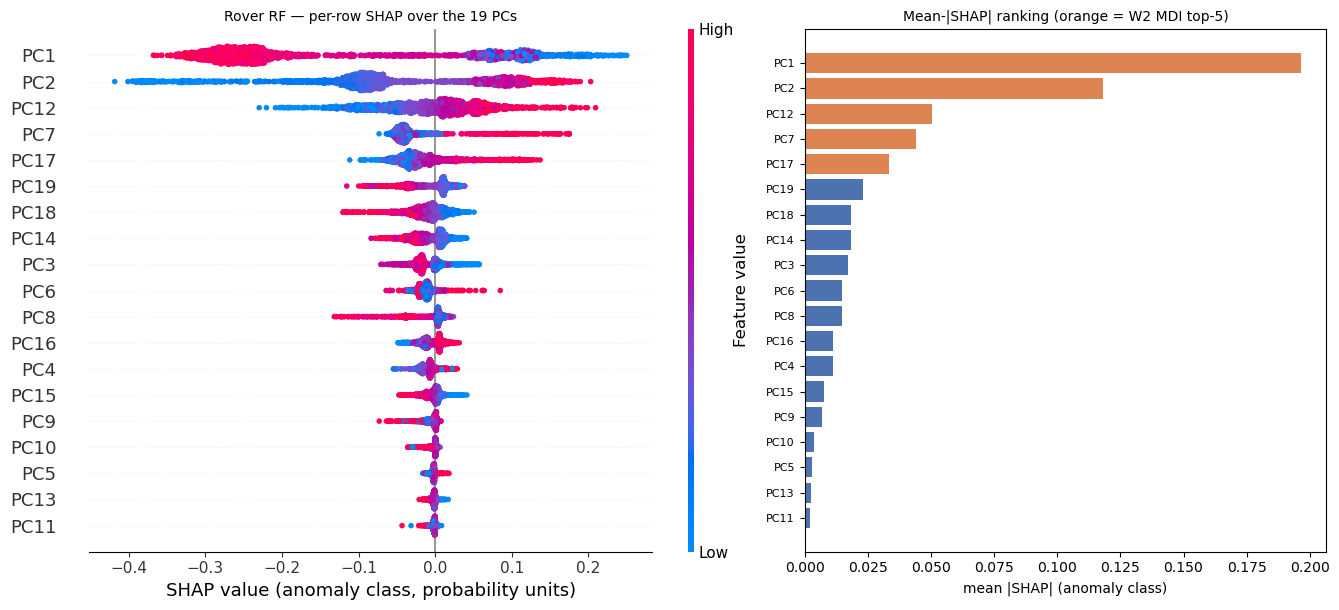

In [3]:
import shap
from scipy.stats import spearmanr
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler

from shared_modules.refit import load_model
from shared_modules.features import build_feature_matrix

# 40-D matrix rebuilt on the canonical block split, exactly as the training path builds it; the
# assert is what makes the attribution below an attribution of the fitted model rather than of a
# lookalike input.
df_rover = pd.read_csv(DATA / 'synthetic_rover_data.csv', index_col='timestamp',
                       parse_dates=True).ffill().bfill()
FM_full, FEAT40, row_idx, LBL_full = build_feature_matrix(df_rover)
split_df = pd.read_csv(DATA / 'rover_stratified_block_split.csv').set_index('row_idx')
purged = split_df.loc[row_idx, 'purged'].values
split_arr = split_df.loc[row_idx, 'split'].values[~purged]
FM, LBL = FM_full[~purged], LBL_full[~purged]
X40 = {s: FM[split_arr == s] for s in ('train', 'val', 'test')}
Y40 = {s: LBL[split_arr == s] for s in ('train', 'val', 'test')}
assert np.array_equal(X40['test'], np.load(DATA / 'temp' / 'X_te_raw.npy'))

rf_bundle = load_model('rover', 'rf')
pipe = rf_bundle['model']
rf_step = pipe.named_steps['rf']
pca = pipe.named_steps['pca']
PC_NAMES = [f'PC{i + 1}' for i in range(pca.n_components_)]

# TreeExplainer sees the RF's own input space: scaler -> PCA(19) applied first, RF alone explained.
Z = {s: pipe[:-1].transform(X40[s]) for s in X40}
sv_rf = shap.TreeExplainer(rf_step).shap_values(Z['test'])[:, :, 1]
recon = shap.TreeExplainer(rf_step).expected_value[1] + sv_rf.sum(1)
proba_rf = rf_step.predict_proba(Z['test'])[:, 1]
print(f'RF test rows explained: {sv_rf.shape[0]} x {sv_rf.shape[1]} PCs | '
      f'additivity max|sum(SHAP)+base - p(anomaly)| = {np.abs(recon - proba_rf).max():.2e}')

rf_mean_abs = pd.Series(np.abs(sv_rf).mean(0), index=PC_NAMES)
SHAP_TOP5 = list(rf_mean_abs.sort_values(ascending=False).index[:5])

# W2 selection ranking: MDI of the analysis-only RF (100 trees, unlimited depth) on the same PCA
# space; the published top-5 values are asserted so the full 19-vector can be used for the rank test.
W2_MDI_TOP5 = {'PC1': 0.1691, 'PC2': 0.1538, 'PC12': 0.1065, 'PC7': 0.0866, 'PC17': 0.0834}
rf_w2 = RandomForestClassifier(n_estimators=100, random_state=SEED, n_jobs=-1)
rf_w2.fit(Z['train'], Y40['train'])
mdi = pd.Series(rf_w2.feature_importances_, index=PC_NAMES)
for pc, v in W2_MDI_TOP5.items():
    assert abs(mdi[pc] - v) < 5e-5, (pc, mdi[pc], v)

rho, p = spearmanr(mdi.values, rf_mean_abs.values)
overlap = sorted(set(SHAP_TOP5) & set(W2_MDI_TOP5), key=lambda s: int(s[2:]))
cmp_tbl = pd.DataFrame({
    'mdi_W2': mdi.round(4), 'mdi_rank': mdi.rank(ascending=False).astype(int),
    'mean_abs_shap': rf_mean_abs.round(4),
    'shap_rank': rf_mean_abs.rank(ascending=False).astype(int),
}).sort_values('shap_rank')
cmp_tbl['W2_top5'] = [pc in W2_MDI_TOP5 for pc in cmp_tbl.index]
display(cmp_tbl)
print(f'\nSHAP top-5   : {SHAP_TOP5}')
print(f'W2 MDI top-5 : {list(W2_MDI_TOP5)}')
print(f'Spearman(MDI, mean|SHAP|) over 19 PCs: rho = {rho:.3f} (p = {p:.2e}) | '
      f'top-5 overlap {len(overlap)}/5 {overlap}')

fig, axes = plt.subplots(1, 2, figsize=(13.5, 6.2),
                         gridspec_kw={'width_ratios': [1.35, 1]})
plt.sca(axes[0])
shap.summary_plot(sv_rf, Z['test'], feature_names=PC_NAMES, show=False, plot_size=None,
                  max_display=19, sort=True)
axes[0].set_xlabel('SHAP value (anomaly class, probability units)')
axes[0].set_title('Rover RF — per-row SHAP over the 19 PCs', fontsize=10)

ordered = rf_mean_abs.sort_values()
axes[1].barh(range(len(ordered)), ordered.values,
             color=[ORANGE if pc in W2_MDI_TOP5 else BLUE for pc in ordered.index])
axes[1].set_yticks(range(len(ordered)))
axes[1].set_yticklabels(ordered.index, fontsize=8)
axes[1].set_xlabel('mean |SHAP| (anomaly class)')
axes[1].set_title('Mean-|SHAP| ranking (orange = W2 MDI top-5)', fontsize=10)
plt.tight_layout(); save(fig, 'rover_rf_shap_pca.png'); plt.show()

The two rankings agree where it matters: SHAP's top five components are the Week-2 selection —
same set, same order — and the full 19-component rank correlation is 0.919. The Week-2 methodology
caveat (MDI is biased toward high-variance features, and PCA components mix sensors) could have
made the selection a method artifact; on this model it is not. Divergence appears only in the tail
components neither method would select.

**From components back to sensors.** Week 2 documented top-5 loadings for PC1–PC5 only, which
leaves the high-index components that carry SHAP mass unresolved. The table below prints the five
largest loadings — signed, ranked by magnitude — for every component in the union of the SHAP top-5
and the Week-2 MDI top-5, read off the PCA fitted inside the deployed pipeline.

In [4]:
# W2 documented loadings for PC1-PC5 only, so the PCs that carry the SHAP mass are resolved to
# raw features here. Loadings are read off the PCA fitted inside the deployed pipeline.
PC_UNION = sorted(set(SHAP_TOP5) | set(W2_MDI_TOP5), key=lambda s: int(s[2:]))

load_rows = []
for pc in PC_UNION:
    k = int(pc[2:]) - 1
    w = pd.Series(pca.components_[k], index=FEAT40)
    for rank, name in enumerate(w.abs().sort_values(ascending=False).index[:5], start=1):
        load_rows.append({'PC': pc, 'var_ratio': round(pca.explained_variance_ratio_[k], 4),
                          'rank': rank, 'feature': name, 'loading': round(w[name], 3)})
loadings_tbl = pd.DataFrame(load_rows).set_index(['PC', 'rank'])
display(loadings_tbl)

print(f'\nPCs resolved: {PC_UNION} '
      f'(SHAP top-5 {SHAP_TOP5}, W2 MDI top-5 {list(W2_MDI_TOP5)})')
print('cumulative variance of the union: '
      f'{pca.explained_variance_ratio_[[int(p[2:]) - 1 for p in PC_UNION]].sum() * 100:.1f}% '
      f'of the 95.1% the 19 components retain')

var_ratio                    feature  loading
PC   rank                                               
PC1  1        0.3164          torque_2_centroid    0.253
     2        0.3164          torque_0_centroid    0.251
     3        0.3164          torque_1_centroid    0.251
     4        0.3164          torque_3_centroid    0.251
     5        0.3164      torque_2_peak_to_mean   -0.244
PC2  1        0.1507                stall_ratio    0.328
     2        0.1507                   torque_3    0.328
     3        0.1507                   torque_2    0.327
     4        0.1507                   torque_0    0.327
     5        0.1507                   torque_1    0.327
PC7  1        0.0334   inter_wheel_std_roll_max    0.430
     2        0.0334  inter_wheel_std_roll_mean    0.420
     3        0.0334            inter_wheel_std    0.374
     4        0.0334                   gps_dlat    0.242
     5        0.0334       torque_0_total_power   -0.193
PC12 1        0.0205            inter_wheel_std    0.481
     2        0.0205                   gps_dlat   -0.386
     3        0.0205          torque_0_dom_freq    0.264
     4        0.0205          torque_1_dom_freq    0.262
     5        0.0205      torque_1_peak_to_mean    0.245
PC17 1        0.0139            inter_wheel_std    0.507
     2        0.0139          torque_3_dom_freq   -0.452
     3        0.0139         torque_2_bandwidth    0.432
     4        0.0139         torque_3_bandwidth   -0.269
     5        0.0139   inter_wheel_std_roll_max   -0.250


PCs resolved: ['PC1', 'PC2', 'PC7', 'PC12', 'PC17'] (SHAP top-5 ['PC1', 'PC2', 'PC12', 'PC7', 'PC17'], W2 MDI top-5 ['PC1', 'PC2', 'PC12', 'PC7', 'PC17'])
cumulative variance of the union: 53.5% of the 95.1% the 19 components retain


The resolved loadings close the gap Week 2 left open: the three previously undocumented
components — PC7, PC12, PC17 — are all dominated by the engineered cross-channel features
(`inter_wheel_std` and its rolling statistics), with GPS deltas and torque spectral terms second.
Five selected components, one theme: the classical model's usable signal concentrates in the
features Week-2 engineering added, which is the attribution-level restatement of the +0.27 F1
those features bought.

**The MLP in its native feature space.** The Rover MLP takes the standardised 40-D matrix directly,
with no PCA in the way, so its attribution is over named sensors and engineered features and needs
no back-projection. `DeepExplainer` handles it — the DeepLIFT rescale rule applied to a
Linear/ReLU/Dropout stack — against a 200-row background sampled from the canonical train split at
seed 42, and the whole 1,901-row test set is explained. The additivity residual is against the
anomaly *logit* here rather than a probability, because the network's forward output is the logit
pair.

**Cross-model comparison.** The MLP's scaler and the RF pipeline's first step are fitted on the
same train rows, so both models consume the same standardised 40-D vector and their attributions
are comparable once the RF's is moved into that space. The map used is
`proj_j = Σ_k mean|SHAP_k| · |loading_kj|`: each component's attributed mass is spread over the raw
features in proportion to how strongly they load on it. It is a magnitude-only projection — signs
cancel across the rows of a component, and a feature that loads weakly on many components
accumulates mass it never earned in any one of them — so the comparison below is a ranking check,
not an equality check.

Rover MLP explained with DeepExplainer | background 200 train rows (seed 42) | 1901 test rows x 40 features
additivity max|sum(SHAP)+base - anomaly logit| = 1.62e-06
MLP top-3 features: ['inter_wheel_std', 'torque_1', 'torque_0']


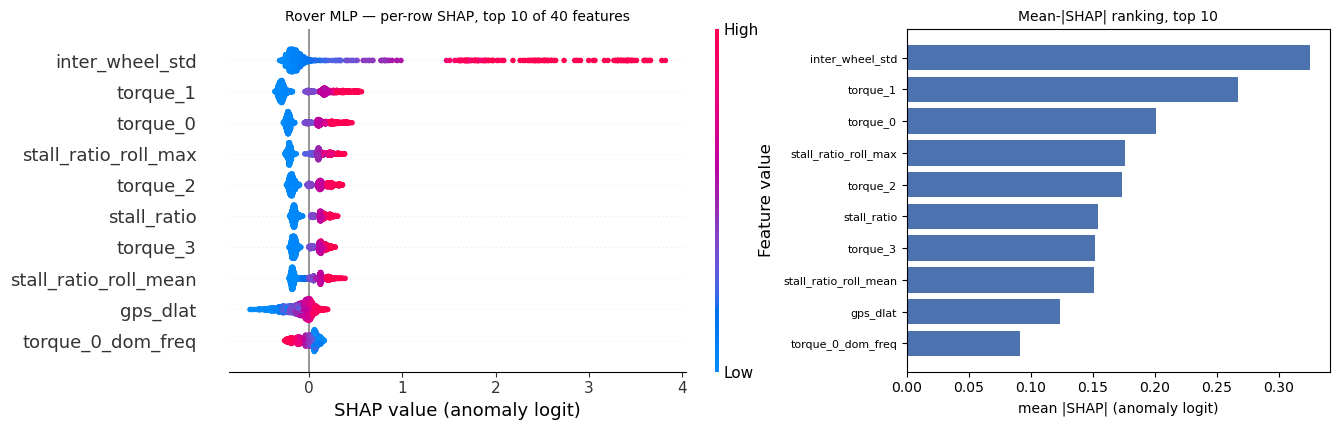

,rf_projected,rf_rank,mlp_mean_abs_shap,mlp_rank
inter_wheel_std,0.1089,1,0.3251,1
torque_1,0.0785,15,0.2673,2
torque_0,0.0786,13,0.2009,3
stall_ratio_roll_max,0.0802,10,0.1762,4
torque_2,0.0785,14,0.1733,5
stall_ratio,0.0787,11,0.1538,6
torque_3,0.0786,12,0.1520,7
stall_ratio_roll_mean,0.0754,22,0.1510,8
gps_dlat,0.0599,28,0.1235,9
torque_0_dom_freq,0.0923,4,0.0909,10



RF projected top-10 : ['inter_wheel_std', 'torque_3_dom_freq', 'torque_2_dom_freq', 'torque_0_dom_freq', 'inter_wheel_std_roll_max', 'torque_3_peak_to_mean', 'torque_1_peak_to_mean', 'torque_0_peak_to_mean', 'torque_2_peak_to_mean', 'stall_ratio_roll_max']
MLP top-10          : ['inter_wheel_std', 'torque_1', 'torque_0', 'stall_ratio_roll_max', 'torque_2', 'stall_ratio', 'torque_3', 'stall_ratio_roll_mean', 'gps_dlat', 'torque_0_dom_freq']
Spearman(RF projected, MLP mean|SHAP|) over 40 features: rho = 0.180 (p = 2.65e-01) | top-10 overlap 3/10 ['inter_wheel_std', 'torque_0_dom_freq', 'stall_ratio_roll_max']


In [5]:
mlp_bundle = load_model('rover', 'mlp')
mlp, mlp_scaler = mlp_bundle['model'], mlp_bundle['scaler']
DEV = next(mlp.parameters()).device

# The MLP's scaler and the RF pipeline's first step are fitted on the same train rows, so the two
# models' inputs are the same standardised 40-D vector and the cross-model comparison is exact.
assert np.allclose(mlp_scaler.mean_, pipe.named_steps['scaler'].mean_)
assert np.allclose(mlp_scaler.scale_, pipe.named_steps['scaler'].scale_)
Xs = {s: mlp_scaler.transform(X40[s]).astype(np.float32) for s in X40}

bg_idx = np.random.default_rng(SEED).choice(len(Xs['train']), 200, replace=False)
background = torch.tensor(Xs['train'][bg_idx], device=DEV)
X_te_t = torch.tensor(Xs['test'], device=DEV)

try:
    expl_mlp = shap.DeepExplainer(mlp, background)
    sv_mlp = expl_mlp.shap_values(X_te_t, check_additivity=True)[:, :, 1]
    EXPLAINER = 'DeepExplainer'
except Exception as err:                       # architecture unsupported by the Deep rules
    print(f'DeepExplainer failed ({type(err).__name__}: {err}); falling back')
    expl_mlp = shap.GradientExplainer(mlp, background)
    sv_mlp = expl_mlp.shap_values(X_te_t)[:, :, 1]
    EXPLAINER = 'GradientExplainer'

with torch.no_grad():
    logit_anom = mlp(X_te_t)[:, 1].cpu().numpy()
base = float(np.atleast_1d(expl_mlp.expected_value)[1])
print(f'Rover MLP explained with {EXPLAINER} | background 200 train rows (seed {SEED}) | '
      f'{sv_mlp.shape[0]} test rows x {sv_mlp.shape[1]} features')
print(f'additivity max|sum(SHAP)+base - anomaly logit| = '
      f'{np.abs(base + sv_mlp.sum(1) - logit_anom).max():.2e}')

mlp_mean_abs = pd.Series(np.abs(sv_mlp).mean(0), index=FEAT40)
mlp_top10 = list(mlp_mean_abs.sort_values(ascending=False).index[:10])
print(f'MLP top-3 features: {mlp_top10[:3]}')

fig, axes = plt.subplots(1, 2, figsize=(13.5, 4.4), gridspec_kw={'width_ratios': [1.35, 1]})
plt.sca(axes[0])
shap.summary_plot(sv_mlp, Xs['test'], feature_names=FEAT40, show=False, plot_size=None,
                  max_display=10, sort=True)
axes[0].set_xlabel('SHAP value (anomaly logit)')
axes[0].set_title('Rover MLP — per-row SHAP, top 10 of 40 features', fontsize=10)

ordered = mlp_mean_abs.sort_values(ascending=False)[:10][::-1]
axes[1].barh(range(10), ordered.values, color=BLUE)
axes[1].set_yticks(range(10)); axes[1].set_yticklabels(ordered.index, fontsize=8)
axes[1].set_xlabel('mean |SHAP| (anomaly logit)')
axes[1].set_title('Mean-|SHAP| ranking, top 10', fontsize=10)
plt.tight_layout(); save(fig, 'rover_mlp_shap_40d.png'); plt.show()

# Cross-model check: push the RF's PC-space attribution back to raw features through the loadings,
# sum_k mean|SHAP_k| * |loading_kj|, then compare rankings over the shared 40-D space.
rf_proj = pd.Series(np.abs(pca.components_).T @ rf_mean_abs.values, index=FEAT40)
rho_x, p_x = spearmanr(rf_proj.values, mlp_mean_abs.values)
rf_top10 = list(rf_proj.sort_values(ascending=False).index[:10])
overlap10 = [f for f in rf_top10 if f in mlp_top10]
cross_tbl = pd.DataFrame({
    'rf_projected': rf_proj.round(4), 'rf_rank': rf_proj.rank(ascending=False).astype(int),
    'mlp_mean_abs_shap': mlp_mean_abs.round(4),
    'mlp_rank': mlp_mean_abs.rank(ascending=False).astype(int),
}).sort_values('mlp_rank').head(15)
display(cross_tbl)
print(f'\nRF projected top-10 : {rf_top10}')
print(f'MLP top-10          : {mlp_top10}')
print(f'Spearman(RF projected, MLP mean|SHAP|) over 40 features: rho = {rho_x:.3f} '
      f'(p = {p_x:.2e}) | top-10 overlap {len(overlap10)}/10 {overlap10}')

Both families put `inter_wheel_std` first, and the MLP's top three are the cross-channel
dispersion plus two raw torques. The formal rank correlation through the loading projection is
0.18 and not significant — but that projection is magnitude-only and mass-spreading, so it washes
out agreement that visibly exists at the top of both rankings; it bounds what this comparison can
show rather than contradicting it. The statement the data supports: the two model families,
trained in different spaces with different inductive biases, select the same engineered
cross-channel feature as their primary anomaly evidence.

## 3. Fari SHAP — Scored Against a Known Truth

Everything above compares one attribution method against another, which can only establish
agreement, not correctness. The Fari interaction-quality label is generated from an explicit linear
score on z-scored features — `topic_coherence` 1.1, `sentiment_score` 0.9, `latency_ms` −0.8,
`follow_up_rate` 0.7, `response_length` 0.3, plus unit Gaussian noise — so here the true importance
ordering exists and SHAP can be scored against it.

Both Fari models are explained on the same 450-row test split, rebuilt exactly as the refit builds
it (stratified 70/15/15, seed 42) and re-scored against each model's manifest F1 before any
attribution. The three series in the figure are each normalised to sum to 1, since RF SHAP is in
probability units, MLP SHAP in logit units, and the generative weights in logit-per-z units — only
the shares are comparable. With five features the Spearman p-value is computed by exact enumeration
of the 120 rank permutations rather than the t-approximation.

Fari test rows: 450 | RF via TreeExplainer, MLP via DeepExplainer (background 200 train rows, seed 42)


,true |weight|,RF mean|SHAP|,MLP mean|SHAP|,true |weight| rank,RF mean|SHAP| rank,MLP mean|SHAP| rank
topic_coherence,0.289,0.351,0.309,1,1,1
sentiment_score,0.237,0.256,0.252,2,2,2
latency_ms,0.211,0.216,0.217,3,3,3
follow_up_rate,0.184,0.150,0.156,4,4,4
response_length,0.079,0.028,0.066,5,5,5


Spearman(RF mean|SHAP|, true |weight|) over the 5 features: rho = 1.000 (exact two-sided p = 0.0167, n=5)
Spearman(MLP mean|SHAP|, true |weight|) over the 5 features: rho = 1.000 (exact two-sided p = 0.0167, n=5)


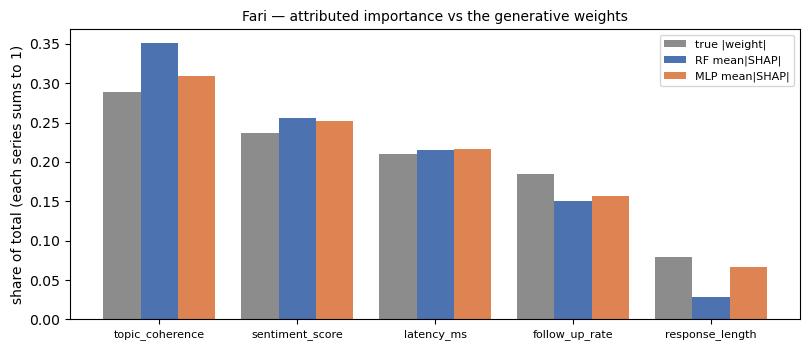

In [6]:
from itertools import permutations

from sklearn.metrics import f1_score
from sklearn.model_selection import train_test_split

# Fari split rebuilt exactly as the refit builds it (stratified 70/15/15, seed 42); each model is
# then fed through its own train-fitted scaler and re-scored against its manifest F1.
FARI_FEATS = ['response_length', 'sentiment_score', 'topic_coherence', 'latency_ms', 'follow_up_rate']
TRUE_W = pd.Series({'topic_coherence': 1.1, 'sentiment_score': 0.9, 'latency_ms': -0.8,
                    'follow_up_rate': 0.7, 'response_length': 0.3}).reindex(FARI_FEATS)

fari_df = pd.read_csv(DATA / 'fari_interaction_quality.csv')
Xf, yf = fari_df[FARI_FEATS].values, fari_df['good_interaction'].values
Xf_tr_raw, Xf_tmp, yf_tr, yf_tmp = train_test_split(Xf, yf, test_size=0.30, stratify=yf,
                                                    random_state=SEED)
_, Xf_te_raw, _, yf_te = train_test_split(Xf_tmp, yf_tmp, test_size=0.50, stratify=yf_tmp,
                                          random_state=SEED)

fari_rf_b, fari_mlp_b = load_model('fari', 'rf'), load_model('fari', 'mlp')
Xf_te_rf = fari_rf_b['scaler'].transform(Xf_te_raw).astype(np.float32)
Xf_te_mlp = fari_mlp_b['scaler'].transform(Xf_te_raw).astype(np.float32)

proba_frf = fari_rf_b['model'].predict_proba(Xf_te_rf)[:, 1]
with torch.no_grad():
    proba_fmlp = torch.softmax(fari_mlp_b['model'](torch.tensor(Xf_te_mlp, device=DEV)),
                               1)[:, 1].cpu().numpy()
for b, proba in ((fari_rf_b, proba_frf), (fari_mlp_b, proba_fmlp)):
    assert abs(f1_score(yf_te, proba >= b['threshold']) - b['metrics']['test_f1']) < 1e-9

sv_frf = shap.TreeExplainer(fari_rf_b['model']).shap_values(Xf_te_rf)[:, :, 1]

fari_bg_idx = np.random.default_rng(SEED).choice(len(Xf_tr_raw), 200, replace=False)
fari_bg = torch.tensor(fari_mlp_b['scaler'].transform(Xf_tr_raw[fari_bg_idx]).astype(np.float32),
                       device=DEV)
try:
    sv_fmlp = shap.DeepExplainer(fari_mlp_b['model'], fari_bg).shap_values(
        torch.tensor(Xf_te_mlp, device=DEV), check_additivity=True)[:, :, 1]
    FARI_EXPLAINER = 'DeepExplainer'
except Exception as err:                       # architecture unsupported by the Deep rules
    print(f'DeepExplainer failed ({type(err).__name__}: {err}); falling back')
    sv_fmlp = shap.GradientExplainer(fari_mlp_b['model'], fari_bg).shap_values(
        torch.tensor(Xf_te_mlp, device=DEV))[:, :, 1]
    FARI_EXPLAINER = 'GradientExplainer'


def _share(v):
    return pd.Series(v, index=FARI_FEATS) / np.sum(v)


shares = pd.DataFrame({
    'true |weight|': _share(TRUE_W.abs().values),
    'RF mean|SHAP|': _share(np.abs(sv_frf).mean(0)),
    'MLP mean|SHAP|': _share(np.abs(sv_fmlp).mean(0)),
}).sort_values('true |weight|', ascending=False)
ranks = shares.rank(ascending=False).astype(int).add_suffix(' rank')
print(f'Fari test rows: {len(yf_te)} | RF via TreeExplainer, MLP via {FARI_EXPLAINER} '
      f'(background 200 train rows, seed {SEED})')
display(pd.concat([shares.round(3), ranks], axis=1))

def exact_spearman(a, b):
    """Spearman rho with the exact permutation p — n=5 is far too small for the t-approximation."""
    rho_e = spearmanr(a, b).statistic
    ra, rb = pd.Series(a).rank().values, pd.Series(b).rank().values
    null = [spearmanr(ra, np.array(p)).statistic for p in permutations(rb)]
    return rho_e, float(np.mean(np.abs(null) >= abs(rho_e) - 1e-12))


for col in ('RF mean|SHAP|', 'MLP mean|SHAP|'):
    rho_f, p_f = exact_spearman(shares['true |weight|'].values, shares[col].values)
    print(f'Spearman({col}, true |weight|) over the 5 features: rho = {rho_f:.3f} '
          f'(exact two-sided p = {p_f:.4f}, n=5)')

fig, ax = plt.subplots(figsize=(8.2, 3.6))
x = np.arange(len(shares)); w = 0.27
for i, (col, c) in enumerate(zip(shares.columns, [GREY, BLUE, ORANGE])):
    ax.bar(x + (i - 1) * w, shares[col].values, w, label=col, color=c)
ax.set_xticks(x); ax.set_xticklabels(shares.index, fontsize=8)
ax.set_ylabel('share of total (each series sums to 1)')
ax.set_title('Fari — attributed importance vs the generative weights', fontsize=10)
ax.legend(fontsize=8)
plt.tight_layout(); save(fig, 'fari_shap_vs_true_weights.png'); plt.show()

Both models recover the generative ordering exactly (ρ = 1.0; exact permutation p = 0.017) — the
attribution pipeline passes the one test where the truth is known. The share profiles differ in
character: the RF exaggerates the strongest feature (0.35 against a true 0.29) and nearly zeroes
the weakest (0.03 against 0.08), while the MLP tracks the whole profile including the tail. Trees
spend their splits where the signal is strong; the small dense network keeps the weak features
alive — the same contrast in miniature that §2 showed on the Rover task.

## 4. Senpai Learner-State Task — a Multi-Class Generalisation Check

Senpai has no dataset anywhere in the repo, and the product documents contain design parameters but
no measured data, so the 2,000-sample task is generated here and every distributional choice is
recorded in the data card below.

**What the product documents pin down, and what they do not.** Senpai models each student as a
latent ability θ updated by Bayesian inference, with item difficulty β in logits and
`P(correct) = γ + (1−γ)·σ(α(θ−β))` — the IRT 3PL model, quoted directly from the engineering
handbook. Under *adaptive* tutoring the GRPO curriculum holds every student near a 57–69 % success
band (δ = 0.5 → 62 %), which makes `correct_rate` nearly level-invariant by construction — so this
dataset simulates a **fixed-difficulty assessment probe** (β = 0, at-expected items), where
`correct_rate` reflects ability. The documents contain no beginner/intermediate/advanced taxonomy —
the closest structure is the teacher-side *below / at / above expected* differentiation, with one
documented class composition of 6 / 18 / 4 students — so the plan's three level names are kept and
mapped onto those bands, with 21.4 / 64.3 / 14.3 % as the class prior.

| feature | generating mechanism | documented anchor | invented (data card) |
| --- | --- | --- | --- |
| `correct_rate` | Binomial(20, 3PL(θ)) / 20 | 3PL formula; θ/β in logits; ZPD 57–69 % band motivates the fixed-β probe | α = 1.2, γ = 0.2, K = 20 items, θ class means ±1.0 (sd 0.5) |
| `response_time_mean` | lognormal around 8 s · e^(−0.35 θ), floor 0.8 s | 1.2 s pseudo-mastery threshold (fast confident answers dip below it); SEND 2–3× multipliers motivate a heavy right tail | base 8 s, slope −0.35, lognormal σ = 0.35 |
| `hint_requests` | Poisson(e^(0.9 − 0.9 θ)) | hints fire on STUM σ > 0.65 (struggle-triggered); escalation after 3 scaffolds | the rate curve |
| `topic_switch_count` | Poisson(3.75 + 1.2·max(0, −θ)) | max 8 min per modality → ~3.75 scheduled switches in a 30-min session; plateau rule adds struggle-driven switches | the extra-switch slope |
| `session_duration` | N(24 + 3θ, 6) clipped to (5, 30] min | SEOM E04 30 min/session cap (the 52-min KPI figure is a daily aggregate and is not used) | the engagement slope |

Labels are the θ-generating class, not thresholds on the features, so class overlap — and therefore
an irreducible error — exists by construction; the θ-Bayes oracle below measures it.

In [7]:
CLASSES = ['beginner', 'intermediate', 'advanced']
PRIOR = np.array([6, 18, 4]) / 28                    # documented Year-5 class composition
THETA = {'beginner': (-1.0, 0.5), 'intermediate': (0.0, 0.5), 'advanced': (1.0, 0.5)}
ALPHA, BETA, GUESS, K_ITEMS = 1.2, 0.0, 0.2, 20      # fixed-difficulty 3PL assessment probe


def generate_senpai(n=2000, seed=SEED):
    rng = np.random.default_rng(seed)
    cls = rng.choice(3, size=n, p=PRIOR)
    theta = np.array([rng.normal(*THETA[CLASSES[c]]) for c in cls])
    p_correct = GUESS + (1 - GUESS) / (1 + np.exp(-ALPHA * (theta - BETA)))
    df = pd.DataFrame(dict(
        correct_rate=rng.binomial(K_ITEMS, p_correct) / K_ITEMS,
        response_time_mean=np.maximum(0.8, 8.0 * np.exp(-0.35 * theta)
                                      * rng.lognormal(0.0, 0.35, n)).round(2),
        hint_requests=rng.poisson(np.exp(0.9 - 0.9 * theta)),
        topic_switch_count=rng.poisson(3.75 + 1.2 * np.maximum(0, -theta)),
        session_duration=np.clip(rng.normal(24 + 3 * theta, 6.0), 5, 30).round(1),
        level=[CLASSES[c] for c in cls]))
    return df, theta


senpai, theta_true = generate_senpai()
senpai.to_csv(DATA / 'senpai_learner_state.csv', index=False)
print(senpai.level.value_counts().to_string())
senpai.groupby('level').mean(numeric_only=True).round(2)

level
intermediate    1273
beginner         437
advanced         290


,correct_rate,response_time_mean,hint_requests,topic_switch_count,session_duration
level,,,,,
advanced,0.81,5.96,1.11,3.92,25.97
beginner,0.40,12.35,6.58,4.90,21.31
intermediate,0.60,8.52,2.73,3.95,23.55


In [8]:
# irreducible-error ceiling: the Bayes rule on the latent theta the classes are defined by
from scipy.stats import norm
from sklearn.metrics import accuracy_score, f1_score

post = np.stack([PRIOR[i] * norm.pdf(theta_true, *THETA[CLASSES[i]]) for i in range(3)])
y_true = np.array([CLASSES.index(l) for l in senpai.level])
oracle_acc = accuracy_score(y_true, post.argmax(0))
oracle_f1 = f1_score(y_true, post.argmax(0), average='macro')
print(f'theta-Bayes oracle: accuracy {oracle_acc:.3f}  macro-F1 {oracle_f1:.3f} — '
      'no feature-based classifier can beat this by more than noise')

theta-Bayes oracle: accuracy 0.812  macro-F1 0.764 — no feature-based classifier can beat this by more than noise


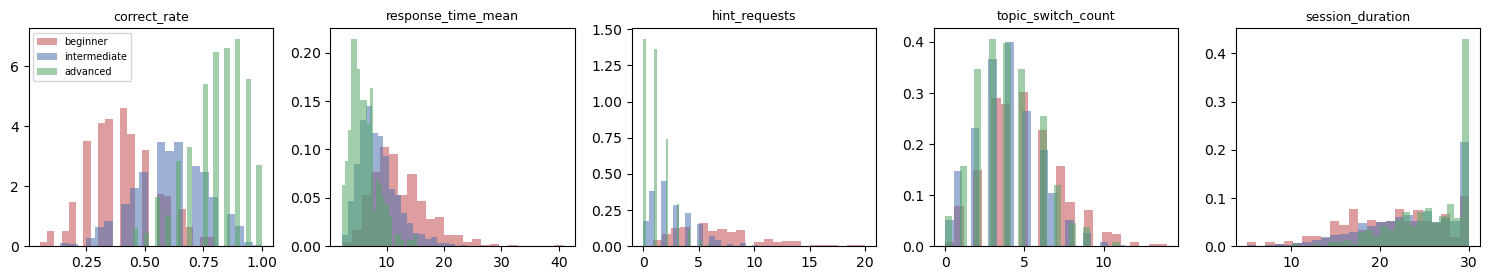

In [9]:
fig, axes = plt.subplots(1, 5, figsize=(15, 2.9))
for ax, col in zip(axes, senpai.columns[:5]):
    for lvl, c in zip(CLASSES, [RED, BLUE, GREEN]):
        ax.hist(senpai.loc[senpai.level == lvl, col], bins=24, alpha=0.55, color=c,
                label=lvl, density=True)
    ax.set_title(col, fontsize=9)
axes[0].legend(fontsize=7)
plt.tight_layout(); save(fig, 'senpai_class_distributions.png'); plt.show()

**Training the classical model.** The classical family is RandomForest (the single classical
model in this project); the grid and protocol mirror the Fari task — rows are independent draws, so
a plain stratified 70/15/15 split is leakage-safe, unlike the block-structured Rover stream.

In [10]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV, StratifiedKFold, train_test_split
from sklearn.metrics import classification_report, confusion_matrix

X = senpai.drop(columns='level').to_numpy()
X_tr, X_tmp, y_tr, y_tmp = train_test_split(X, y_true, test_size=0.3, stratify=y_true,
                                            random_state=SEED)
X_va, X_te, y_va, y_te = train_test_split(X_tmp, y_tmp, test_size=0.5, stratify=y_tmp,
                                          random_state=SEED)
print(f'split sizes: train {len(y_tr)} / val {len(y_va)} / test {len(y_te)} (70/15/15)')

grid = GridSearchCV(RandomForestClassifier(class_weight='balanced', random_state=SEED),
                    {'n_estimators': [100, 200], 'max_depth': [5, 10, None]},
                    scoring='f1_macro', cv=StratifiedKFold(5, shuffle=True, random_state=SEED))
grid.fit(X_tr, y_tr)
rf_senpai = grid.best_estimator_
print('grid winner:', grid.best_params_, f'| CV macro-F1 {grid.best_score_:.4f}')
print(f'val macro-F1 {f1_score(y_va, rf_senpai.predict(X_va), average="macro"):.4f}')

split sizes: train 1400 / val 300 / test 300 (70/15/15)


grid winner: {'max_depth': 10, 'n_estimators': 200} | CV macro-F1 0.6596
val macro-F1 0.6799


              precision    recall  f1-score   support

    beginner      0.614     0.773     0.685        66
intermediate      0.820     0.691     0.750       191
    advanced      0.500     0.651     0.566        43

    accuracy                          0.703       300
   macro avg      0.645     0.705     0.667       300
weighted avg      0.729     0.703     0.709       300



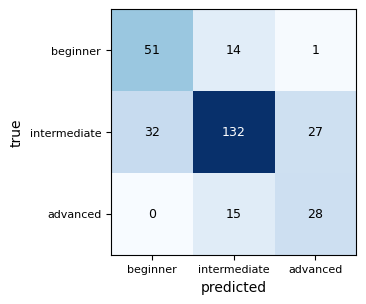

test macro-F1 0.6667 (oracle ceiling 0.764)
single-sample latency 8.697 ms -> PASS vs the 100 ms Senpai conversational-turn gate


In [11]:
y_pred = rf_senpai.predict(X_te)
print(classification_report(y_te, y_pred, target_names=CLASSES, digits=3))
cm = confusion_matrix(y_te, y_pred)
fig, ax = plt.subplots(figsize=(3.6, 3.2))
im = ax.imshow(cm, cmap='Blues')
for i in range(3):
    for j in range(3):
        ax.text(j, i, cm[i, j], ha='center', va='center',
                color='white' if cm[i, j] > cm.max() / 2 else 'black', fontsize=9)
ax.set_xticks(range(3)); ax.set_xticklabels(CLASSES, fontsize=8)
ax.set_yticks(range(3)); ax.set_yticklabels(CLASSES, fontsize=8)
ax.set_xlabel('predicted'); ax.set_ylabel('true')
plt.tight_layout(); save(fig, 'senpai_confusion.png'); plt.show()

t = timeit.timeit(lambda: rf_senpai.predict(X_te[:1]), number=2000) / 2000
test_f1 = f1_score(y_te, y_pred, average='macro')
print(f'test macro-F1 {test_f1:.4f} (oracle ceiling {oracle_f1:.3f})')
print(f'single-sample latency {1000*t:.3f} ms -> {"PASS" if 1000*t < 100 else "FAIL"} '
      'vs the 100 ms Senpai conversational-turn gate')

**Multi-class SHAP.** TreeExplainer yields one attribution set per class; the summary plots
below show per-class top features with feature-value colouring, and the bar chart the mean-absolute
magnitude across classes.

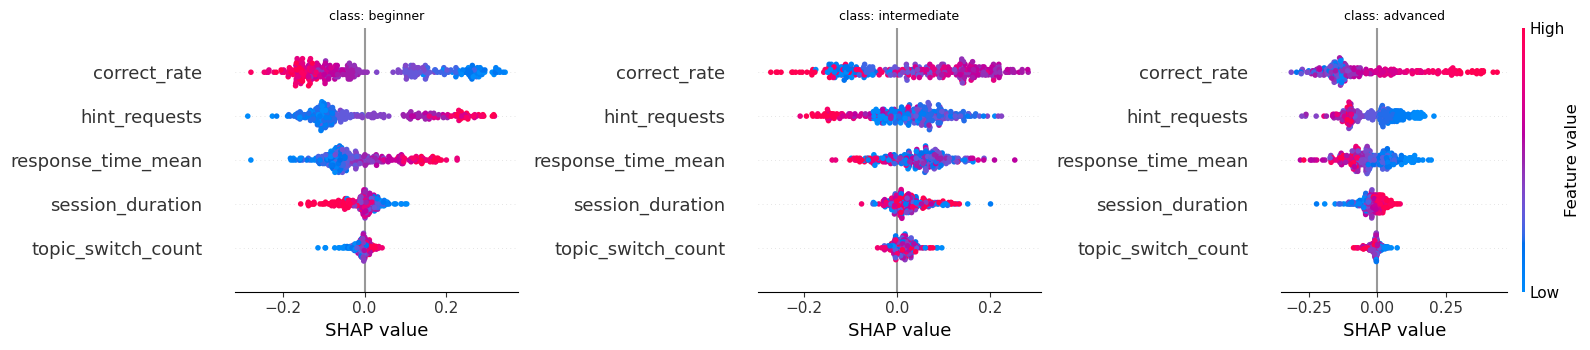

,beginner,intermediate,advanced
correct_rate,0.1445,0.1182,0.1498
response_time_mean,0.0743,0.0642,0.0703
hint_requests,0.1229,0.0711,0.0814
topic_switch_count,0.0135,0.0177,0.0147
session_duration,0.0314,0.0320,0.0319


top-3 overall: ['correct_rate', 'hint_requests', 'response_time_mean']


In [12]:
import shap

expl = shap.TreeExplainer(rf_senpai)
sv = expl.shap_values(X_te)
feat_names = list(senpai.columns[:5])

sv_list = [sv[:, :, k] for k in range(sv.shape[2])] if isinstance(sv, np.ndarray) and sv.ndim == 3 else sv
fig, axes = plt.subplots(1, 3, figsize=(16, 3.6))
for k, (lvl, ax) in enumerate(zip(CLASSES, axes)):
    plt.sca(ax)
    shap.summary_plot(sv_list[k], X_te, feature_names=feat_names, show=False, plot_size=None,
                      color_bar=(k == 2))
    ax.set_title(f'class: {lvl}', fontsize=9)
    ax.set_xlabel('SHAP value')
plt.tight_layout(); save(fig, 'senpai_shap_summary.png'); plt.show()

mean_abs = pd.DataFrame({lvl: np.abs(sv_list[k]).mean(0) for k, lvl in enumerate(CLASSES)},
                        index=feat_names)
display(mean_abs.round(4))
print('top-3 overall:', list(mean_abs.mean(1).sort_values(ascending=False).index[:3]))

The attribution matches the generator's design and adds one reading the design did not state.
Top-3 overall — `correct_rate`, `hint_requests`, `response_time_mean` — are exactly the three
features whose class-conditional distributions the data card separates most, and the beeswarm
directions are the pedagogically sensible ones (high correct rate pushes away from beginner and
toward advanced; hints do the reverse). The addition: `hint_requests` carries nearly twice the
attribution for the beginner class (0.123) as for intermediate (0.071) — struggle signals identify
who needs help more sharply than they separate the upper levels, which is the asymmetry a
differentiation product would want. `topic_switch_count` is attributed almost nothing anywhere,
matching its weak class signal by construction; a fielded model would earn its switches from
engagement telemetry the synthetic set does not carry. Test macro-F1 0.667 against the θ-oracle's
0.764: the model extracts ~87 % of the information the features hold, and the smallest class
(advanced, 43 test rows) is where the rest is lost.

## 5. Attention — Recap, and What It Does on the Misses

The attention analysis itself is Week-3 work and is cited, not redone: median fault/normal
attention selectivity 5.3× (above 1 in 98 % of 267 eligible anomalous test windows) against 1.15×
for the LSTM hidden-state norm, and Week 4's trajectory transformer moving its attention
centre-of-mass from history step 6.7 to 3.1 across the five prediction horizons. Under the Week-3
capacity control the Transformer's F1 edge is parameters rather than attention, so attention's
value in this project is diagnostic — and one diagnostic question was left open.

**Attention on the misses.** Week 3 found the Transformer's attention lands on the true fault span
and, separately, that detection collapses on stuck-type faults — 39.5 % caught against 76.2 % for
slip. The two findings were never joined: if attention is on the fault span even when the window is
missed, the miss is a decision-boundary failure rather than a localisation failure, and the fix is
a different one.

Neither `rover_windows.npz` nor the source stream stores a fault type, so Week 3's proxy is reused:
the world core draws slip time-to-live from [10, 40) steps and stuck from [30, 80), which makes any
fault run longer than 40 steps unambiguously stuck-type. Per-step fault masks come from the
canonical anchor rows — test window *j* covers rows `[a_j − 50, a_j)` — and the selectivity ratio is
mean attention received on fault steps over mean attention on normal steps, so it is defined only
for windows holding both. The Transformer is replayed at its canonical 0.87 threshold and asserted
against the manifest confusion matrix first.

The count of independent fault episodes behind the eligible windows is printed with the medians.
Windows overlap by construction, so the window count is not a sample size, and any comparison
between the detected and missed groups has to be read against that number.

Transformer replayed at threshold 0.87: test F1 0.7782 (manifest 0.7782)



stuck-type (anchor run > 40 steps) anomalous test windows: 129, detection rate 0.395
of those, both fault and normal steps in-window: 99, detection rate 0.455; 30 dropped as fully covered (ratio undefined), 6 of which were detected
independent fault episodes behind those 99 windows: 2 (anchor rows [3499, 10572], run lengths [56, 73]) — the windows overlap by construction


,n,median,q1,q3,frac_gt1
outcome,,,,,
detected,45,7.028,2.879,25.471001,0.933
missed,54,8.654,7.004,9.620000,1.000


n  median_ratio  median_coverage
episode outcome                                    
3499    detected  45         7.028             22.0
        missed     5        10.084             28.0
10572   missed    49         8.617             25.0


median selectivity ratio: detected 7.03 (n=45) vs missed 8.65 (n=54)
window-level Mann-Whitney U = 1150, p = 0.65 — windows overlap and tile 2 episodes, so this is not an independent-sample test


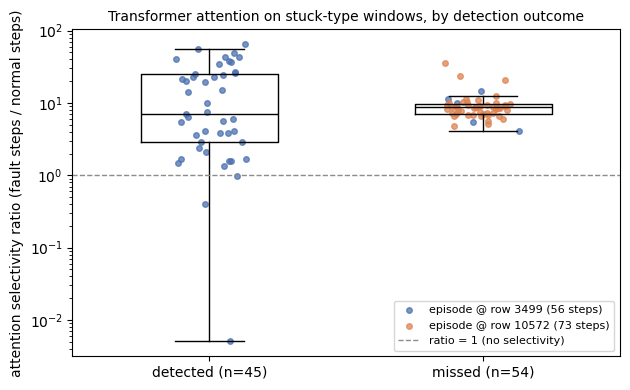

In [13]:
from scipy.stats import mannwhitneyu
from sklearn.metrics import confusion_matrix, f1_score

# w=50 window tensors, per-channel standardised on train statistics — the exact input the
# Transformer was trained and scored on; the manifest confusion matrix is the check.
win = np.load(DATA / 'rover_windows.npz')
Xw_raw = {s: win[f'X_{s}_w50'] for s in ('train', 'val', 'test')}
yw = {s: win[f'y_{s}'].astype(np.int64) for s in ('train', 'val', 'test')}
ch_mean = Xw_raw['train'].reshape(-1, 11).mean(0)
ch_std = Xw_raw['train'].reshape(-1, 11).std(0) + 1e-8
Xw50_te = ((Xw_raw['test'] - ch_mean) / ch_std).astype(np.float32)

tr_bundle = load_model('rover', 'transformer')
tf_model, THR = tr_bundle['model'], tr_bundle['threshold']
with torch.no_grad():
    proba_te_t = torch.softmax(tf_model(torch.tensor(Xw50_te, device=DEV)), 1)[:, 1].cpu().numpy()
pred_te_t = (proba_te_t >= THR).astype(int)
assert confusion_matrix(yw['test'], pred_te_t).ravel().tolist() == tr_bundle['metrics']['confusion_matrix']
print(f'Transformer replayed at threshold {THR:.2f}: test F1 {f1_score(yw["test"], pred_te_t):.4f} '
      f'(manifest {tr_bundle["metrics"]["test_f1"]:.4f})')

# Neither rover_windows.npz nor synthetic_rover_data.csv stores a fault type, so W3's proxy is
# reused: slip TTL is drawn from [10, 40) steps and stuck from [30, 80), making runs longer than
# 40 steps unambiguously stuck-type. Per-step fault masks come from the canonical anchor rows.
lbl_all = pd.read_csv(DATA / 'synthetic_rover_data.csv')['anomaly_label'].values
anchors = split_df.reset_index()
anchors = anchors.loc[(~anchors['purged']) & (anchors['split'] == 'test'), 'row_idx'].values
assert np.array_equal(lbl_all[anchors], yw['test'])
fault_masks_te = np.stack([lbl_all[a - 50:a] for a in anchors])

run_len = np.zeros(len(lbl_all), dtype=int)
i = 0
while i < len(lbl_all):
    if lbl_all[i] == 1:
        j = i
        while j < len(lbl_all) and lbl_all[j] == 1:
            j += 1
        run_len[i:j] = j - i
        i = j
    else:
        i += 1


def episode_start(a):
    s = a
    while lbl_all[s - 1] == 1:
        s -= 1
    return s


def batched_attn_received(model, X, batch_size=256):
    """Final-layer attention received per key timestep: head-averaged, then query-averaged."""
    model.eval()
    outs = []
    with torch.no_grad():
        for b in range(0, len(X), batch_size):
            h = model.pos_enc(model.input_proj(torch.tensor(X[b:b + batch_size], device=DEV)))
            for li, layer in enumerate(model.transformer_encoder.layers):
                if li == len(model.transformer_encoder.layers) - 1:
                    _, aw = layer.self_attn(h, h, h, need_weights=True)
                    outs.append(aw.mean(dim=1).cpu().numpy())
                h = layer(h)
    return np.concatenate(outs, axis=0)


attn_te = batched_attn_received(tf_model, Xw50_te)

anom_idx = np.where(yw['test'] == 1)[0]
stuck_idx = anom_idx[run_len[anchors[anom_idx]] > 40]
rows = []
for j in stuck_idx:
    m = fault_masks_te[j].astype(bool)
    if m.all() or not m.any():
        continue                       # ratio undefined without both step types in the window
    rows.append({'idx': j, 'anchor': anchors[j], 'episode': episode_start(anchors[j]),
                 'run_len': run_len[anchors[j]], 'coverage': int(m.sum()),
                 'ratio': attn_te[j][m].mean() / attn_te[j][~m].mean(),
                 'outcome': 'detected' if pred_te_t[j] == 1 else 'missed'})
stuck_df = pd.DataFrame(rows)

n_full = len(stuck_idx) - len(stuck_df)
full_det = pred_te_t[stuck_idx].sum() - (stuck_df.outcome == 'detected').sum()
print(f'\nstuck-type (anchor run > 40 steps) anomalous test windows: {len(stuck_idx)}, '
      f'detection rate {pred_te_t[stuck_idx].mean():.3f}')
print(f'of those, both fault and normal steps in-window: {len(stuck_df)}, detection rate '
      f'{(stuck_df.outcome == "detected").mean():.3f}; {n_full} dropped as fully covered '
      f'(ratio undefined), {full_det} of which were detected')
print(f'independent fault episodes behind those {len(stuck_df)} windows: '
      f'{stuck_df.episode.nunique()} (anchor rows {[int(e) for e in sorted(stuck_df.episode.unique())]}, '
      f'run lengths {[int(r) for r in sorted(stuck_df.run_len.unique())]}) — '
      'the windows overlap by construction')

summary = stuck_df.groupby('outcome')['ratio'].agg(
    n='size', median='median', q1=lambda s: s.quantile(0.25), q3=lambda s: s.quantile(0.75),
    frac_gt1=lambda s: (s > 1).mean()).round(3)
display(summary)
display(stuck_df.groupby(['episode', 'outcome']).agg(
    n=('ratio', 'size'), median_ratio=('ratio', 'median'),
    median_coverage=('coverage', 'median')).round(3))

det = stuck_df.loc[stuck_df.outcome == 'detected', 'ratio'].values
mis = stuck_df.loc[stuck_df.outcome == 'missed', 'ratio'].values
u, p_u = mannwhitneyu(det, mis)
print(f'\nmedian selectivity ratio: detected {np.median(det):.2f} (n={len(det)}) vs '
      f'missed {np.median(mis):.2f} (n={len(mis)})')
print(f'window-level Mann-Whitney U = {u:.0f}, p = {p_u:.3g} — windows overlap and tile '
      f'{stuck_df.episode.nunique()} episodes, so this is not an independent-sample test')

fig, ax = plt.subplots(figsize=(6.4, 4.0))
groups = ['detected', 'missed']
ax.boxplot([det, mis], tick_labels=[f'detected (n={len(det)})', f'missed (n={len(mis)})'],
           widths=0.5, showfliers=False, medianprops={'color': 'black'})
rng_jit = np.random.default_rng(SEED)
for ep, colour in zip(sorted(stuck_df.episode.unique()), [BLUE, ORANGE]):
    sub = stuck_df[stuck_df.episode == ep]
    xpos = sub.outcome.map({g: k + 1 for k, g in enumerate(groups)}).values
    ax.scatter(xpos + rng_jit.uniform(-0.14, 0.14, len(sub)), sub.ratio.values, s=16, alpha=0.75,
               color=colour, label=f'episode @ row {ep} ({sub.run_len.iloc[0]} steps)')
ax.axhline(1.0, color=GREY, ls='--', lw=1, label='ratio = 1 (no selectivity)')
ax.set_yscale('log')
ax.set_ylabel('attention selectivity ratio (fault steps / normal steps)')
ax.set_title('Transformer attention on stuck-type windows, by detection outcome', fontsize=10)
ax.legend(fontsize=8)
plt.tight_layout(); save(fig, 'attention_stuck_detected_vs_missed.png'); plt.show()

The one-sided claim survives the sample structure; the two-sided one does not. The eligible
windows tile only two independent stuck episodes — one 90 % detected, one missed entirely — so
comparing detected against missed medians (7.0 vs 8.7) compares episode identity, not populations,
and the figure colours points by episode to keep that visible. What stands is the missed episode
itself: every one of its 49 windows has attention selectivity above 1, median 8.7×, while the
classification head calls all of them normal. The stuck-type recall ceiling is therefore not a
localisation failure — the evidence is found and then discarded at the decision boundary. That
moves the Week-3 finding one layer deeper: the 39.5 % recall is a property of the classification
head under the training distribution, not of the encoder, and any Week-8 fix should start there.

## 6. RL Value and Saliency — What the Patrol Policy Reads

SHAP and attention above explain a classifier's output on one sample. A policy's counterpart is
two objects: the critic's value of the state it is standing in, and the sensitivity of the action
logits to each observation channel. Both are read here on the Week-6 patrol policy — PPO 250k
BC-init, train seed 0, the Week-6 return leader among deployable policies — against the
behaviour-cloning prior it was fine-tuned from, so the question is not only what the policy attends
to but what 250k environment steps of PPO changed about it.

The two policies are loaded the way `rl/harness/evaluate.py` loads them: the SB3 zip holds no
normaliser, so the observation is rescaled once by `NormalizeObs` outside the model, and the BC
policy is retrained deterministically from the Week-2 offline transition table (seed 42) because
Week 5 never saved a checkpoint. Both reproduce their published world-0 return to the digit, which
is what makes the attribution below an attribution of the evaluated policy rather than of a
lookalike.

Everything in this section runs on one episode: evaluation world seed 0, the first of the ten
Week-6 worlds, at the full-loop 9,600-step horizon. That is one train seed on one world, not the
five-by-ten protocol the Week-6 return table is built on — this section explains a policy, it does
not rank policies.

In [14]:
from stable_baselines3 import PPO

from shared_modules.rl_eval import POL_DIR, ART_DIR, EVAL_WORLD_SEEDS, make_eval_env, rollout
from rl.harness.evaluate import train_bc
from rl.rover_env import STATE_COLS, ACTION_NAMES, LOW_SOC

RL_WORLD = EVAL_WORLD_SEEDS[0]                 # canonical evaluation world
PPO_TAG, PPO_SEED = 'ppo250k_bcinit', 0
CHANNELS = list(STATE_COLS)
ACTIONS = [ACTION_NAMES[i] for i in range(5)]
BC_PUBLISHED = 5075.349999999189               # w6_eval.json bc_offline per_world[0]

ppo = PPO.load(POL_DIR / f'{PPO_TAG}_s{PPO_SEED}.zip', device='cpu')
ppo.policy.set_training_mode(False)

# The zip holds no normaliser: the evaluation path feeds it a NormalizeObs-wrapped env, so the
# observation is rescaled exactly once, outside the model. Everything below keeps that contract.
env = make_eval_env(RL_WORLD, norm=True)
ppo_stats, trace = rollout(lambda o: ppo.predict(o, deterministic=True)[0], env, record=True)
env.close()

published = json.loads((ART_DIR / f'eval_{PPO_TAG}_s{PPO_SEED}.json').read_text())['per_world'][0]
assert abs(ppo_stats['ret'] - published) < 1e-6, (ppo_stats['ret'], published)

# attribution needs the BC logits, not the argmax closure alone
bc_predict, bc_net = train_bc(return_net=True)
env = make_eval_env(RL_WORLD, norm=True)
bc_stats = rollout(bc_predict, env)
env.close()

# Re-deriving the greedy action from the loaded object must reproduce the recorded one, or the
# observation has been normalised a different number of times than during evaluation.
assert (ppo.predict(trace['obs_norm'].astype(np.float32), deterministic=True)[0]
        == trace['action']).all()

print(f'PPO  {PPO_TAG}_s{PPO_SEED}  world {RL_WORLD}: return {ppo_stats["ret"]:.2f} '
      f'(published {published:.2f}) | {ppo_stats["length"]} steps | {ppo_stats["terminated_reason"]}')
print(f'BC   retrained (seed 42) world {RL_WORLD}: return {bc_stats["ret"]:.2f} '
      f'(published {BC_PUBLISHED:.2f}) | {bc_stats["length"]} steps | {bc_stats["terminated_reason"]}')
print('greedy actions replayed from the checkpoint match the recorded trace on all',
      len(trace['action']), 'steps')

PPO  ppo250k_bcinit_s0  world 0: return 3955.55 (published 3955.55) | 5129 steps | stuck_timeout
BC   retrained (seed 42) world 0: return 5075.35 (published 5075.35) | 9109 steps | stuck_timeout
greedy actions replayed from the checkpoint match the recorded trace on all 5129 steps


**The value trace.** The upper panel is the critic's `V(s_t)` along the episode, the lower one the
full action distribution `π(a | s_t)` on the same axis; both are sampled every 10th step, since
per-step detail over 5k steps is not legible and the quantities are smooth at that scale. Shaded
spans mark the steps where the ground-truth anomaly label is active — the label the observation
withholds — and the two vertical markers are the step at which the main route first reads as
blocked ahead and the step at which the branch reads as blocked too.

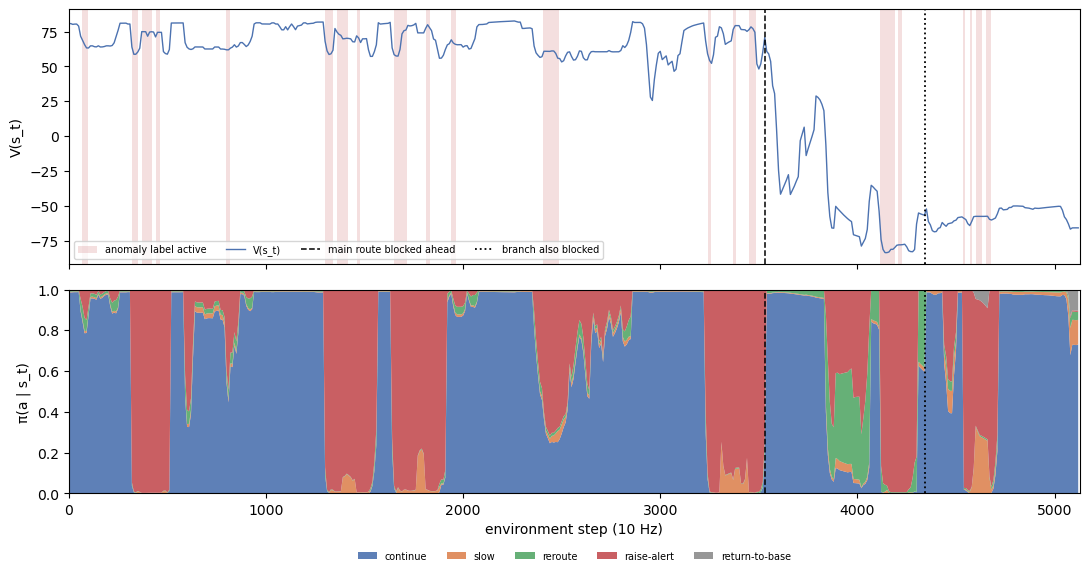

V(s) over the episode: min -83.3  mean 32.7  max 82.6
main-route blockage onset at step [3529] | branch blockage onset at step [4342]
21 anomaly episodes covering 698 of 5129 steps


In [15]:
DS = 10                       # x-axis downsample: 5k steps of per-step detail is not readable
OBS_T = torch.as_tensor(trace['obs_norm'], dtype=torch.float32)
ACT_COLORS = [BLUE, ORANGE, GREEN, RED, GREY]


def ppo_logits(x):
    """Raw pre-softmax action logits, along the path `bc_pretrain_flat` fits and `predict` reads."""
    p = ppo.policy
    return p.action_net(p.mlp_extractor.forward_actor(p.extract_features(x)))


with torch.no_grad():
    V = ppo.policy.predict_values(OBS_T).squeeze(-1).numpy()
    PI = torch.softmax(ppo_logits(OBS_T), -1).numpy()
assert (PI.argmax(1) == trace['action']).all()       # the manual logit path is the acting path


def flag_runs(mask):
    """[start, end) index pairs of each contiguous True run."""
    edges = np.flatnonzero(np.diff(np.concatenate(([0], mask.astype(np.int8), [0]))) != 0)
    return edges.reshape(-1, 2)


def fig_value_trace():
    """Critic value and action distribution over one full patrol episode."""
    t = np.arange(len(V))
    main_on = flag_runs(trace['main_blocked'].astype(bool))[:, 0]
    branch_on = flag_runs(trace['branch_blocked'].astype(bool))[:, 0]
    fig, axes = plt.subplots(2, 1, figsize=(11, 5.8), sharex=True,
                             gridspec_kw=dict(height_ratios=[1.25, 1]))
    ax = axes[0]
    for k, (a, b) in enumerate(flag_runs(trace['label'].astype(bool))):
        ax.axvspan(a, b, color=RED, alpha=0.18, lw=0, label='anomaly label active' if not k else None)
    ax.plot(t[::DS], V[::DS], color=BLUE, lw=1.0, label='V(s_t)')
    ax.set_ylabel('V(s_t)')

    ax = axes[1]
    ax.stackplot(t[::DS], PI[::DS].T, colors=ACT_COLORS, labels=ACTIONS, alpha=0.9)
    ax.set_ylim(0, 1)
    ax.set_xlim(0, len(V))
    ax.set_xlabel('environment step (10 Hz)')
    ax.set_ylabel('π(a | s_t)')

    # the route-state markers carry both panels, so a change in the action mix can be read against
    # the event that preceded it
    for i, ax in enumerate(axes):
        for k, x in enumerate(main_on):
            ax.axvline(x, color='k', ls='--', lw=1.1,
                       label='main route blocked ahead' if not i and not k else None)
        for k, x in enumerate(branch_on):
            ax.axvline(x, color='k', ls=':', lw=1.3,
                       label='branch also blocked' if not i and not k else None)
    axes[0].legend(fontsize=7, ncol=4, loc='lower left')
    # a stackplot fills the whole axis, so its legend has to sit outside it
    axes[1].legend(fontsize=7, ncol=5, loc='upper center', bbox_to_anchor=(0.5, -0.24),
                   frameon=False)
    fig.tight_layout()
    save(fig, 'rl_value_trace.png')
    return fig


fig_value_trace(); plt.show()
print(f'V(s) over the episode: min {V.min():.1f}  mean {V.mean():.1f}  max {V.max():.1f}')
print('main-route blockage onset at step', flag_runs(trace['main_blocked'].astype(bool))[:, 0].tolist(),
      '| branch blockage onset at step',
      flag_runs(trace['branch_blocked'].astype(bool))[:, 0].tolist())
print(f'{len(flag_runs(trace["label"].astype(bool)))} anomaly episodes covering '
      f'{trace["label"].sum()} of {len(V)} steps')

The trace shows the mismatch the Week-6 tables measured. The critic prices route state correctly —
V holds 50–85 through normal patrol, dips on anomaly spans, falls off a cliff at the main-route
blockage and settles near −57 once both routes read blocked — but the action panel barely answers:
reroute mass appears only around steps 3,850–4,150, late and never dominant, and after the branch
also blocks the policy returns to `continue` at 74 % inside a state its own critic scores as a dead
end, until the stuck timeout ends the episode. Alert mass tracks the shaded anomaly spans but also
fires on wide unshaded stretches (~2,300–2,800 and ~3,250–3,520) — the 241 false alerts per 1,000
normal steps of the Week-6 table, visible on a single trace. A value head that sees the problem
attached to an actor that does not act on it is the single-policy view of the failure the
node-level semi-MDP repaired at the decision-rate level.

**Conditions.** The event masks are the ones `rl_eval.rollout` counts on, so a row here indexes the
same steps as the published `P(alert | anomaly)` and `P(reroute | block)`: an anomaly step is one
where the label is active whatever the route state, and a blockage-approach step is a main route
blocked within 150 m with the branch still open. The two overlap where a fault occurs near a
blockage; the count is printed below. Steps where both routes are blocked are held out as their own
row rather than folded into the blockage-approach one — the rover is in a dead end there, not
choosing a detour.

In [16]:
# Conditions follow the event counters in `rl_eval.rollout`, so a row here indexes the same steps
# as the published P(alert | anomaly) and P(reroute | block): `anomaly` is the label whatever the
# route state, `blockage-approach` is a blocked main route with the branch still open.
_lab = trace['label'].astype(bool)
_main = trace['main_blocked'].astype(bool)
_branch = trace['branch_blocked'].astype(bool)

CONDITIONS = {'normal patrol': ~_lab & ~_main,
              'anomaly': _lab,
              'blockage-approach': _main & ~_branch}
VALUE_ROWS = dict(CONDITIONS, **{'dead end (both blocked)': _main & _branch,
                                 'low SoC (< 20 %)': trace['soc'] < LOW_SOC})


def event_value_table():
    rows = []
    for name, m in VALUE_ROWS.items():
        n = int(m.sum())
        acts = np.bincount(trace['action'][m], minlength=5) if n else np.zeros(5, int)
        rows.append({'condition': name, 'steps': n,
                     'mean V(s)': round(float(V[m].mean()), 1) if n else None,
                     'sd V(s)': round(float(V[m].std()), 1) if n else None,
                     'mean reward': round(float(trace['reward'][m].mean()), 3) if n else None,
                     'modal action': ACTIONS[int(acts.argmax())] if n else '—',
                     'modal share': f'{acts.max() / n:.0%}' if n else '—'})
    return pd.DataFrame(rows)


display(event_value_table())
print(f'anomaly steps that are also a blockage-approach: {int((_lab & _main & ~_branch).sum())}'
      f' of {int(_lab.sum())} — the anomaly and blockage rows overlap by that much')
print(f'battery over the episode: {trace["soc"].min():.1f}–{trace["soc"].max():.1f} %, so the '
      f'low-SoC condition is empty on the canonical start (SoC = 100 %, {len(V)} steps)')

,condition,steps,mean V(s),sd V(s),mean reward,modal action,modal share
0,normal patrol,2996,69.7,10.2,0.300,continue,74%
1,anomaly,698,34.6,59.2,3.961,raise-alert,90%
2,blockage-approach,813,-39.8,39.4,0.655,continue,49%
3,dead end (both blocked),787,-56.8,5.7,0.731,continue,74%
4,low SoC (< 20 %),0,NaN,NaN,NaN,—,—


anomaly steps that are also a blockage-approach: 94 of 698 — the anomaly and blockage rows overlap by that much
battery over the episode: 80.5–99.8 %, so the low-SoC condition is empty on the canonical start (SoC = 100 %, 5129 steps)


The conditioning states the mismatch numerically: mean V drops from 69.7 on normal patrol to −39.8
on blockage-approach and −56.8 in the dead end, yet the modal action stays `continue` in both route
conditions (49 % and 74 %); only the anomaly condition flips the modal action, to raise-alert at
90 %. Low SoC never occurs on a full-battery start — SoC ends the episode at 80.5 % — so the
battery condition has no rows here, exactly as the Week-6 low-SoC ablation predicted for this
dispatch charge.

**Input-gradient saliency.** For each step, `∂ logit(a) / ∂ obs` where `a` is that policy's own
greedy action at that state, differentiated on the *normalised* observation the network is fed.
Normalised units are what make the nine channels comparable: the raw vector mixes torque in Nm with
LiDAR distances in metres and SoC in per cent, so a raw-space gradient would rank channels by their
units. The per-condition bars are `|·|` averaged over the steps of that condition.

The two networks are different sizes with different logit scales, so the absolute panels compare
the *shape* of the attribution rather than the height of the bars; the same figure normalised to a
within-policy share follows for the direct ranking comparison.

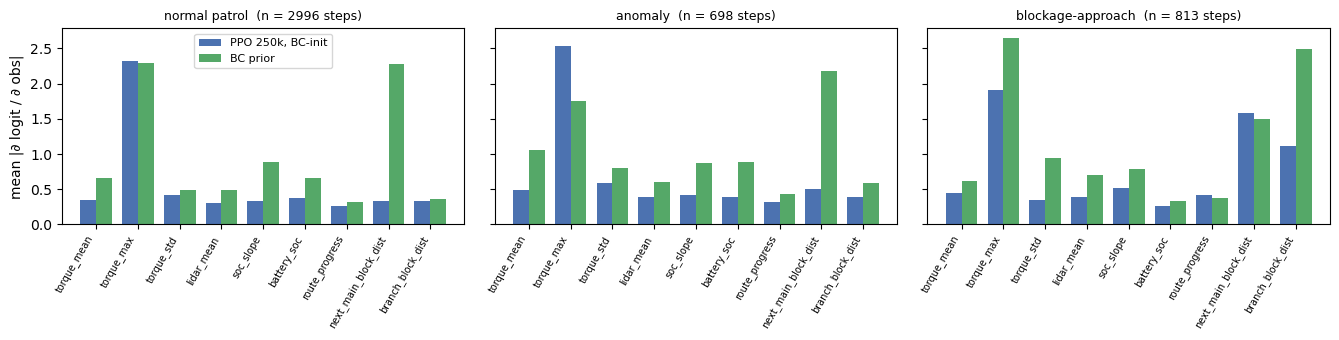

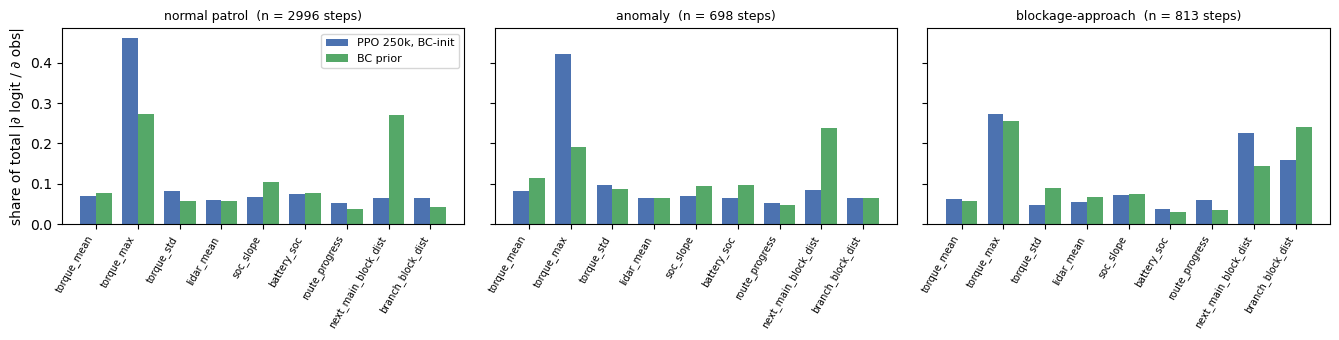

PPO and BC pick the same action on 61.7% of the 5129 trace steps
mean |grad| over all steps:  PPO 0.625  BC 1.056


PPO 250k, BC-init                            \
                         normal patrol anomaly blockage-approach   
torque_mean                      0.352   0.495             0.446   
torque_max                       2.323   2.537             1.909   
torque_std                       0.418   0.583             0.343   
lidar_mean                       0.307   0.388             0.391   
soc_slope                        0.339   0.417             0.516   
battery_soc                      0.378   0.393             0.258   
route_progress                   0.263   0.319             0.422   
next_main_block_dist             0.326   0.510             1.579   
branch_block_dist                0.329   0.394             1.115   

                          BC prior                            
                     normal patrol anomaly blockage-approach  
torque_mean                  0.662   1.054             0.615  
torque_max                   2.295   1.748             2.652  
torque_std                   0.494   0.798             0.948  
lidar_mean                   0.485   0.609             0.704  
soc_slope                    0.885   0.867             0.789  
battery_soc                  0.664   0.884             0.331  
route_progress               0.315   0.433             0.371  
next_main_block_dist         2.271   2.182             1.501  
branch_block_dist            0.359   0.595             2.493

In [17]:
def input_saliency(logit_fn, obs_t, action=None):
    """|∂ logit(a) / ∂ obs| per step, taken on the normalised observation the policy is fed.

    One batched backward yields every step's own gradient because row i's logit depends only on
    row i. `action` fixes which logit is differentiated; the default is the policy's own greedy
    action at that state.
    """
    x = obs_t.clone().requires_grad_(True)
    logits = logit_fn(x)
    a = logits.argmax(1).detach() if action is None else \
        torch.as_tensor(np.broadcast_to(action, len(obs_t)).copy(), dtype=torch.int64)
    logits.gather(1, a[:, None]).sum().backward()
    return x.grad.abs().numpy(), a.numpy()


SAL, ACT = {}, {}
SAL['PPO'], ACT['PPO'] = input_saliency(ppo_logits, OBS_T)
SAL['BC'], ACT['BC'] = input_saliency(bc_net, OBS_T)
assert (ACT['PPO'] == trace['action']).all()

SAL_MEAN = {k: pd.DataFrame({c: v[m].mean(0) for c, m in CONDITIONS.items()}, index=CHANNELS)
            for k, v in SAL.items()}
POLICY_LABEL = {'PPO': 'PPO 250k, BC-init', 'BC': 'BC prior'}


def fig_saliency(fname, normalise=False):
    """Per-channel input gradient by event condition, PPO against the BC prior it started from."""
    fig, axes = plt.subplots(1, len(CONDITIONS), figsize=(13.5, 3.5), sharey=True)
    xs, w = np.arange(len(CHANNELS)), 0.38
    for ax, (c, m) in zip(axes, CONDITIONS.items()):
        for i, (k, col) in enumerate(zip(['PPO', 'BC'], [BLUE, GREEN])):
            v = SAL_MEAN[k][c]
            ax.bar(xs + (i - 0.5) * w, v / v.sum() if normalise else v, w, color=col,
                   label=POLICY_LABEL[k])
        ax.set_xticks(xs)
        ax.set_xticklabels(CHANNELS, rotation=60, ha='right', fontsize=7)
        ax.set_title(f'{c}  (n = {int(m.sum())} steps)', fontsize=9)
    axes[0].set_ylabel('share of total |∂ logit / ∂ obs|' if normalise
                       else 'mean |∂ logit / ∂ obs|')
    axes[0].legend(fontsize=8)
    fig.tight_layout()
    save(fig, fname)
    return fig


fig_saliency('rl_saliency_conditions.png'); plt.show()
# The two networks have different logit scales, so the absolute panels above compare shapes, not
# heights; the same figure as a within-policy share makes the ranking directly comparable.
fig_saliency('rl_saliency_conditions_share.png', normalise=True); plt.show()

print(f'PPO and BC pick the same action on {(ACT["BC"] == ACT["PPO"]).mean():.1%} of the '
      f'{len(OBS_T)} trace steps')
print('mean |grad| over all steps:  PPO', round(float(SAL['PPO'].mean()), 3),
      ' BC', round(float(SAL['BC'].mean()), 3))
display(pd.concat({POLICY_LABEL[k]: v.round(3) for k, v in SAL_MEAN.items()}, axis=1))

Fine-tuning reallocated attention in one direction. BC keeps a standing dual sensitivity —
`torque_max` and `next_main_block_dist` carry comparable gradient in every condition (27 % / 27 %
of its total on normal patrol) — while PPO collapses onto `torque_max` (46 % on normal patrol,
42 % on anomaly steps) and leaves `next_main_block_dist` under 9 % everywhere except when a
blockage is already inside sensor range. The feature level matches the behavioural deltas the
Week-6 report measured (reroute 0.84 → 0.34, false alarms 55 → 241): PPO's reward-driven updates
grew the alert pathway, which pays on every anomaly step, and let the navigation pathway inherited
from BC atrophy. The two policies pick the same greedy action on only 61.7 % of trace steps —
the fine-tuned policy is not a sharpened copy of its prior.

**One logit per trigger.** The bars above differentiate whichever action the policy actually chose,
which on a normal patrol step is `continue` and says little about the alert head. This last view
fixes the logit instead: the `raise-alert` logit on anomaly steps and the `reroute` logit on
blockage-approach steps — each action scored on the condition it exists for, whether or not the
policy takes it there. The table then collects the top-2 channels of every view.

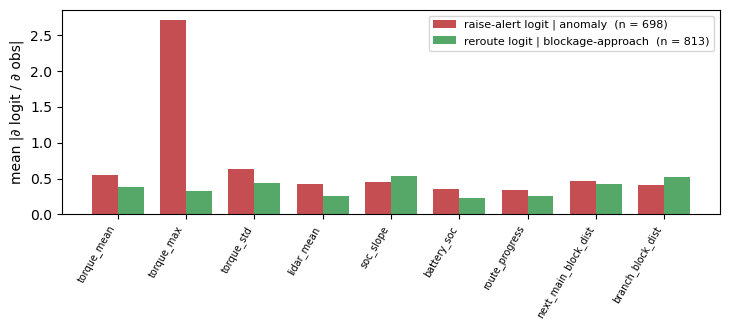

,policy,condition,steps,top-1,|grad| 1,share 1,top-2,|grad| 2,share 2
0,"PPO 250k, BC-init",normal patrol,2996,torque_max,2.323,46%,torque_std,0.418,8%
1,"PPO 250k, BC-init",anomaly,698,torque_max,2.537,42%,torque_std,0.583,10%
2,"PPO 250k, BC-init",blockage-approach,813,torque_max,1.909,27%,next_main_block_dist,1.579,23%
3,BC prior,normal patrol,2996,torque_max,2.295,27%,next_main_block_dist,2.271,27%
4,BC prior,anomaly,698,next_main_block_dist,2.182,24%,torque_max,1.748,19%
5,BC prior,blockage-approach,813,torque_max,2.652,25%,branch_block_dist,2.493,24%
6,"PPO 250k, BC-init",raise-alert logit | anomaly,698,torque_max,2.718,43%,torque_std,0.639,10%
7,"PPO 250k, BC-init",reroute logit | blockage-approach,813,soc_slope,0.543,16%,branch_block_dist,0.527,16%


In [18]:
# Per-action view, PPO only: each trigger condition is scored on the logit of the action it is
# supposed to trigger, rather than on whichever action the policy actually took there.
TRIGGER = {'raise-alert logit | anomaly': (3, CONDITIONS['anomaly']),
           'reroute logit | blockage-approach': (2, CONDITIONS['blockage-approach'])}
PER_ACTION = pd.DataFrame({name: input_saliency(ppo_logits, OBS_T, a)[0][m].mean(0)
                           for name, (a, m) in TRIGGER.items()}, index=CHANNELS)


def fig_per_action():
    fig, ax = plt.subplots(figsize=(7.4, 3.4))
    xs, w = np.arange(len(CHANNELS)), 0.38
    for i, (name, col) in enumerate(zip(PER_ACTION.columns, [RED, GREEN])):
        ax.bar(xs + (i - 0.5) * w, PER_ACTION[name], w, color=col,
               label=f'{name}  (n = {int(TRIGGER[name][1].sum())})')
    ax.set_xticks(xs)
    ax.set_xticklabels(CHANNELS, rotation=60, ha='right', fontsize=7)
    ax.set_ylabel('mean |∂ logit / ∂ obs|')
    ax.legend(fontsize=8)
    fig.tight_layout()
    save(fig, 'rl_saliency_per_action.png')
    return fig


fig_per_action(); plt.show()


def top_channels(series, n_steps, k=2):
    s = series.sort_values(ascending=False)
    share = s / s.sum()
    out = {'steps': n_steps}
    for i in range(k):
        out[f'top-{i + 1}'] = s.index[i]
        out[f'|grad| {i + 1}'] = round(float(s.iloc[i]), 3)
        out[f'share {i + 1}'] = f'{share.iloc[i]:.0%}'
    return out


summary = [dict(policy=POLICY_LABEL[k], condition=c,
                **top_channels(SAL_MEAN[k][c], int(CONDITIONS[c].sum())))
           for k in ['PPO', 'BC'] for c in CONDITIONS]
summary += [dict(policy='PPO 250k, BC-init', condition=name,
                 **top_channels(PER_ACTION[name], int(m.sum())))
            for name, (_, m) in TRIGGER.items()]
pd.DataFrame(summary)

The per-logit view is the sharpest statement in this section. The raise-alert logit is essentially
a `torque_max` detector — 43 % of its gradient on one channel — consistent with the generator's
fault signature being a torque surge (21.5 → 44.1 Nm on anomaly steps; point-biserial r = 0.49
between `torque_max` and the label on this trace). The reroute logit has no feature at all: its
largest channel carries 16 % of the gradient, barely above the uniform 11 %. A head with no sharp
input dependence cannot fire reliably, which is the mechanistic form of the Week-6 finding that
rerouting is the behaviour the flat 10 Hz policy cannot learn and the node-level semi-MDP can
(0.34 against 0.82). The observation-only IRL policy failed for the complementary reason — its
recovered reward could not encode the alert rule the expert acted on — so across all three lenses
the alert pathway is the learnable part of this task, and routing is the hard part.

## 7. Learning Curves — Bias, Variance, and the Compressibility Echo

The diagnosis question: at the full 9.7k training rows, are the Rover default (MLP) and the
classical model (RF) limited by capacity or by data? Rows inside a block are serially dependent, so
the curve grows the training set by whole blocks in a fixed seed-42 order — never by rows, which
would leak future rows of a partially included block into training. At every size the full
protocol is refit from scratch: standardisation on the subset, class weights on the subset, early
stopping and the decision threshold tuned on the untouched canonical validation fold.

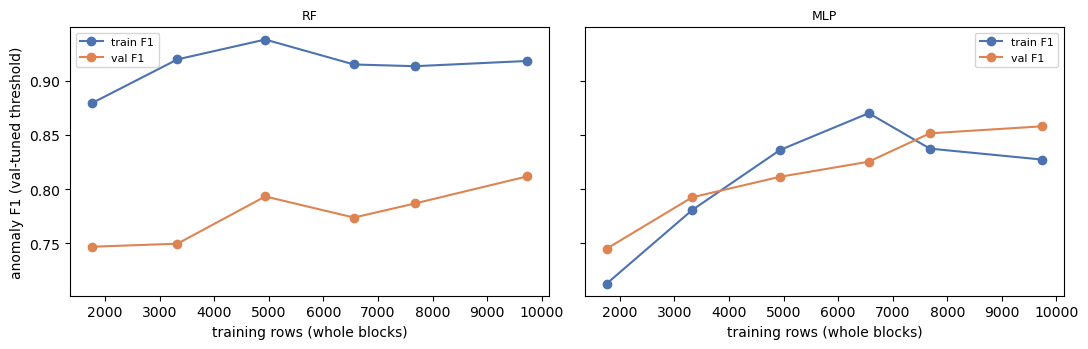

,model,n,train_f1,val_f1
0,RF,1760,0.8794,0.7469
1,MLP,1760,0.7129,0.7451
2,RF,3325,0.9197,0.7497
3,MLP,3325,0.7807,0.7925
4,RF,4935,0.9380,0.7932
5,MLP,4935,0.8361,0.8114
6,RF,6560,0.9150,0.7738
7,MLP,6560,0.8701,0.8253
8,RF,7680,0.9134,0.7868
9,MLP,7680,0.8374,0.8515


In [19]:
from sklearn.decomposition import PCA
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import f1_score
from shared_modules.features import build_feature_matrix
from shared_modules.refit import _run_mlp, tune_threshold, predict_proba, DEVICE

df_clean = pd.read_csv(DATA / 'synthetic_rover_data.csv', index_col='timestamp',
                       parse_dates=True).ffill().bfill()
fm_full, feat_names, row_idx, lab_full = build_feature_matrix(df_clean)
split_df = pd.read_csv(DATA / 'rover_stratified_block_split.csv').set_index('row_idx')
purged = split_df.loc[row_idx, 'purged'].values
fm, lab = fm_full[~purged], lab_full[~purged]
spl = split_df.loc[row_idx, 'split'].values[~purged]
blocks = split_df.loc[row_idx, 'block_id'].values[~purged]

tr, va = spl == 'train', spl == 'val'
X_va_raw, y_va = fm[va], lab[va]
train_blocks = pd.unique(blocks[tr])
rng = np.random.default_rng(SEED)
block_order = rng.permutation(train_blocks)

FRACS = [0.15, 0.3, 0.5, 0.7, 0.85, 1.0]
rows = []
for frac in FRACS:
    take = block_order[:max(2, round(frac * len(block_order)))]
    m = tr & np.isin(blocks, take)
    scaler = StandardScaler().fit(fm[m])
    X_sub, y_sub = scaler.transform(fm[m]).astype(np.float32), lab[m]
    X_vas = scaler.transform(X_va_raw).astype(np.float32)

    rf = Pipeline([('sc', StandardScaler()), ('pca', PCA(0.95)),
                   ('rf', RandomForestClassifier(n_estimators=200, max_depth=10,
                                                 class_weight='balanced', random_state=SEED))])
    rf.fit(fm[m], y_sub)
    thr_rf, _ = tune_threshold(y_va, rf.predict_proba(X_va_raw)[:, 1])
    rows.append(dict(model='RF', n=int(m.sum()),
                     train_f1=f1_score(y_sub, (rf.predict_proba(fm[m])[:, 1] >= thr_rf).astype(int)),
                     val_f1=f1_score(y_va, (rf.predict_proba(X_va_raw)[:, 1] >= thr_rf).astype(int))))

    mlp, _, _ = _run_mlp(40, (64, 32), 'relu', 0.3, 'sgd_momentum', X_sub, y_sub, X_vas, y_va)
    thr, _ = tune_threshold(y_va, predict_proba(mlp, X_vas, DEVICE))
    rows.append(dict(model='MLP', n=int(m.sum()),
                     train_f1=f1_score(y_sub, (predict_proba(mlp, X_sub, DEVICE) >= thr).astype(int)),
                     val_f1=f1_score(y_va, (predict_proba(mlp, X_vas, DEVICE) >= thr).astype(int))))

lc = pd.DataFrame(rows)
fig, axes = plt.subplots(1, 2, figsize=(11, 3.6), sharey=True)
for ax, name in zip(axes, ['RF', 'MLP']):
    d = lc[lc.model == name]
    ax.plot(d.n, d.train_f1, 'o-', color=BLUE, label='train F1')
    ax.plot(d.n, d.val_f1, 'o-', color=ORANGE, label='val F1')
    ax.set_title(name, fontsize=9)
    ax.set_xlabel('training rows (whole blocks)')
    ax.legend(fontsize=8)
axes[0].set_ylabel('anomaly F1 (val-tuned threshold)')
plt.tight_layout(); save(fig, 'learning_curves_rf_mlp.png'); plt.show()
lc.round(4)

Neither model is capacity-starved, and neither has seen enough data. The MLP's validation F1
rises monotonically through the final doubling (0.745 at 1.8k rows to 0.858 at 9.7k) with a
train–val gap under 0.05 over most of the curve — low variance, moderate bias, and a curve that
has not flattened: more blocks would still buy performance. The RF carries a persistent
0.10–0.13 train–val gap at every size — the variance-dominated profile — and its full-data
validation score (0.81) is what the MLP reaches with half the blocks. The val-tuned threshold
favours the validation split by construction, so the trends are the informative content, not the
train–val ordering at any one point. And the compressibility echo from the CNC project: at 18 %
of the training blocks the MLP is already within 0.11 of its full-data score — most of the signal
lives in a small fraction of the data here, as it lived in a small fraction of the features
there.

## 8. What Explains What

One feature story spans every family. The engineered cross-channel dispersion features are the
primary anomaly evidence for the classical model (three of its five selected components resolve to
`inter_wheel_std` terms), for the MLP (top-1 in its native space), and — in surge form, as
`torque_max` — for the RL alert head. The attribution machinery passes its ground-truth test where
one exists: on Fari both model families recover the generative importance ordering exactly. The
transformer's attention is a working localiser even on the windows the classifier misses, which
relocates the stuck-type recall ceiling from the encoder to the decision head. And the RL policy
pair shows fine-tuning as feature reallocation — PPO grew the alert pathway and let the navigation
attention it inherited from BC atrophy, which is the attribution-level form of its behavioural
trade. The week's most surprising finding is the missed-episode attention result: the model that
fails stuck-type detection is not failing to find the evidence — it finds it and discards it.